# 구글 드라이브 연결

In [1]:
# 구글 드라이브 연결(데이터 로드를 위해서)
from google.colab import drive

drive.mount('/content/data')

Drive already mounted at /content/data; to attempt to forcibly remount, call drive.mount("/content/data", force_remount=True).


# Install

In [2]:
!pip install -r "/content/data/MyDrive/ai_lecture/6. Recommendation System/3. 개인화 추천 예제/requirements.txt"

# [영화 평가 데이터](https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset/data)
- 이 파일에는 Full MovieLens 데이터셋에 등록된 45,000편의 영화에 대한 메타데이터가 포함되어 있습니다.
- 이 데이터셋은 2017년 7월 이전에 개봉한 영화로 구성되어 있습니다. 데이터 포인트에는 출연진, 제작진, 줄거리 키워드, 예산, 수익, 포스터, 개봉일, 언어, 제작사, 국가, TMDB 투표 수 및 투표 평균 등이 포함됩니다.
- 이 데이터세트에는 45,000편의 영화에 대해 27만 명의 사용자가 작성한 2,600만 건의 평점이 포함된 파일도 포함되어 있습니다.
- 평점은 1점부터 5점까지의 점수로 매겨지며, GroupLens 공식 웹사이트에서 수집되었습니다.

## 데이터(파일) 설명

- movies_metadata.csv
  - 주요 영화 메타데이터 파일입니다.
  - Full MovieLens 데이터세트에 포함된 45,000편의 영화에 대한 정보가 포함되어 있습니다.
  - 포스터, 배경, 예산, 수익, 개봉일, 언어, 제작 국가 및 제작사 등의 정보가 포함됩니다.
- links_small.csv
  - 전체 데이터 세트의 9,000개 영화 중 작은 하위 세트의 TMDB 및 IMDB ID를 포함합니다.
- ratings_small.csv
  - 9,000편의 영화에 대한 700명의 사용자의 100,000개 평가의 하위 집합입니다.

# 데이터

## 데이터 로드

In [3]:
# 데이터 분석에 사용할 라이브러리
import numpy as np
import pandas as pd

DATA_PATH = "/content/data/MyDrive/ai_lecture/6. Recommendation System/data/Movies Dataset/"

### Movies Metadata

In [4]:
movies_metadata = pd.read_csv(DATA_PATH+'movies_metadata.csv')

movies_metadata.shape

/tmp/ipython-input-4-2843536420.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies_metadata = pd.read_csv(DATA_PATH+'movies_metadata.csv')


(45466, 24)

In [5]:
movies_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [6]:
movies_metadata[['id', 'imdb_id', 'title']].head()

,id,imdb_id,title
0,862,tt0114709,Toy Story
1,8844,tt0113497,Jumanji
2,15602,tt0113228,Grumpier Old Men
3,31357,tt0114885,Waiting to Exhale
4,11862,tt0113041,Father of the Bride Part II


> 노이즈 데이터 제거

In [7]:
# 노이즈 데이터 확인
movies_metadata.iloc[[19730, 29503, 35587]][['id', 'imdb_id', 'title']]

,id,imdb_id,title
19730,1997-08-20,0,NaN
29503,2012-09-29,0,NaN
35587,2014-01-01,0,NaN


In [8]:
# 노이즈 데이터 제거
movies_metadata = movies_metadata.drop([19730, 29503, 35587])

#### Links Small

In [9]:
links_small = pd.read_csv(DATA_PATH+'links_small.csv')

links_small.shape

(9125, 3)

In [10]:
# 결측치 제거 및 데이터 형변환
links_small = links_small[links_small['tmdbId'].notnull()]['tmdbId'].astype('int')
links_small.shape

(9112,)

In [11]:
# links_small에 포함된 id만 사용
movies_metadata_small = movies_metadata[movies_metadata['id'].isin(links_small.astype('str'))]
movies_metadata_small.shape

(9099, 24)

### Ratings Small

In [12]:
ratings_small = pd.read_csv(DATA_PATH+"ratings_small.csv")

ratings_small.shape

(100004, 4)

In [13]:
ratings_small.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100004 entries, 0 to 100003
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100004 non-null  int64  
 1   movieId    100004 non-null  int64  
 2   rating     100004 non-null  float64
 3   timestamp  100004 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [14]:
ratings_small.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


### Merge(합치기)

> 합치기전 사전작업

In [15]:
# 데이터 타입 변환
movies_metadata_small['id'] = movies_metadata_small['id'].astype('int')

# 컬럼명 변경
movies_metadata_small.rename(columns={
    'id':'movieId'
}, inplace=True)

/tmp/ipython-input-15-2362054378.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_metadata_small['id'] = movies_metadata_small['id'].astype('int')
/tmp/ipython-input-15-2362054378.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_metadata_small.rename(columns={


> 데이터 합치기

In [16]:
ratings = ratings_small[['userId',	'movieId',	'rating']].merge(movies_metadata_small[['movieId', 'title']], on=['movieId'])

ratings.shape

(32136, 4)

In [17]:
ratings.head()

,userId,movieId,rating,title
0,1,1371,2.5,Rocky III
1,1,1405,1.0,Greed
2,1,2105,4.0,American Pie
3,1,2193,2.0,My Tutor
4,1,2294,2.0,Jay and Silent Bob Strike Back


## 데이터 분석

> rating(별점) 분포도 확인

In [18]:
ratings['rating'].describe()

,rating
count,32136.000000
mean,3.585558
std,1.047206
min,0.500000
25%,3.000000
50%,4.000000
75%,4.000000
max,5.000000


> 사용자 분석

In [19]:
print(f"전체 사용자의 수: {ratings['userId'].nunique()}")

# 사용자별 영화 본 수
ratings['userId'].value_counts()

전체 사용자의 수: 671


,count
userId,
564,656
547,437
452,376
311,350
15,346
...,...
374,3
71,3
446,2


> 영화 분석

In [20]:
print(f"전체 영화 수: {ratings['title'].nunique()}")

# 영화별 사용자가 본 수
ratings['title'].value_counts()

전체 영화 수: 1535


,count
title,
Terminator 3: Rise of the Machines,324
The Million Dollar Hotel,311
Solaris,305
The 39 Steps,291
Monsoon Wedding,274
...,...
Eragon,1
I Can't Sleep,1
Flesh for Frankenstein,1


## 데이터 전처리

### 데이터 정규화
- 각 영화의 평균 평점을 빼는 방식으로 데이터를 정규화할 것입니다.

In [21]:
ratings_by_title = ratings.groupby(['title'])\
  .agg({'rating':'mean'})\
  .rename(columns={
    'rating':'mean'
  })\
  .reset_index()

# 영화별 평점의 평균값
ratings_by_title.head()

,title,mean
0,...And God Created Woman,4.000000
1,10 Items or Less,4.318182
2,10 Things I Hate About You,2.642857
3,"10,000 BC",3.833333
4,11'09''01 - September 11,2.000000


In [22]:
# 영화별 평균 추가
ratings = ratings.merge(ratings_by_title, on=['title'])

ratings.head()

,userId,movieId,rating,title,mean
0,1,1371,2.5,Rocky III,3.053191
1,1,1405,1.0,Greed,3.032609
2,1,2105,4.0,American Pie,3.478723
3,1,2193,2.0,My Tutor,3.202381
4,1,2294,2.0,Jay and Silent Bob Strike Back,3.273585


In [23]:
# 평점 정규화
ratings['norm_rating'] = ratings.apply(lambda row: row['rating'] - row['mean'], axis=1)

ratings[['title', 'rating', 'mean', 'norm_rating']].head()

,title,rating,mean,norm_rating
0,Rocky III,2.5,3.053191,-0.553191
1,Greed,1.0,3.032609,-2.032609
2,American Pie,4.0,3.478723,0.521277
3,My Tutor,2.0,3.202381,-1.202381
4,Jay and Silent Bob Strike Back,2.0,3.273585,-1.273585


### 정규성 변환

<Axes: ylabel='Count'>

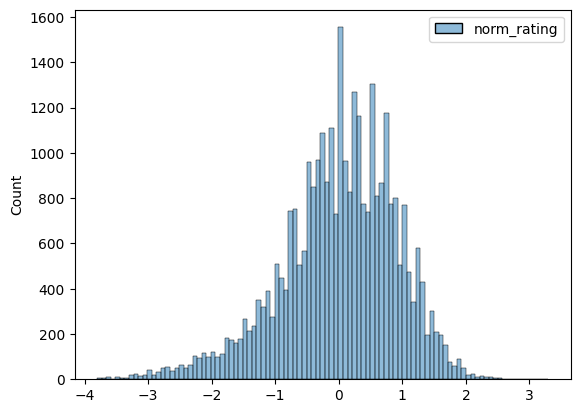

In [24]:
import seaborn as sns

# 왜도 확인
# -> 정규분포를 따르기 때문에 따로 정규성 변환 작업하지 않음
sns.histplot(ratings[['norm_rating']])

### new rating with MinMax Scaling

In [25]:
# 스케일링 적용(범위1~5)
def minmax_scaling(data, min, max):
  scale = max - min
  return 1 + ((data - min) / scale)*4

In [26]:
# 최소값
rating_min = ratings['norm_rating'].min()
# 최대값
rating_max = ratings['norm_rating'].max()

# 스케일링 적용(범위1~5)
ratings['new_rating'] = ratings['norm_rating'].map(
  lambda x: minmax_scaling(x, rating_min, rating_max)
)

ratings[['title', 'rating', 'norm_rating', 'new_rating']].head()

,title,rating,norm_rating,new_rating
0,Rocky III,2.5,-0.553191,2.832340
1,Greed,1.0,-2.032609,1.998271
2,American Pie,4.0,0.521277,3.438105
3,My Tutor,2.0,-1.202381,2.466338
4,Jay and Silent Bob Strike Back,2.0,-1.273585,2.426195


In [27]:
ratings[['rating', 'new_rating']].describe()

,rating,new_rating
count,32136.000000,32136.000000
mean,3.585558,3.144219
std,1.047206,0.516465
min,0.500000,1.000000
25%,3.000000,2.862328
50%,4.000000,3.179455
75%,4.000000,3.509915
max,5.000000,5.000000


> new_rating이 rating보다 안정적인 정규분포를 따르는 것을 볼 수 있다.

<Axes: ylabel='Count'>

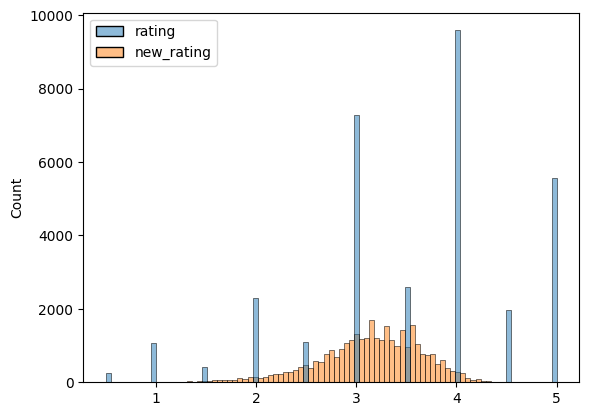

In [28]:
sns.histplot(ratings[['rating', 'new_rating']])

## 데이터 결측치 제거

In [29]:
print(f"movies.shape: {ratings.shape}")
(ratings.isnull().sum() / ratings.shape[0])\
  .round(4)\
  .sort_values(ascending=False)

movies.shape: (32136, 7)


,0
userId,0.0
movieId,0.0
rating,0.0
title,0.0
mean,0.0
norm_rating,0.0
new_rating,0.0


# Model Based Collaborative Filtering

## [LightFM](https://making.lyst.com/lightfm/docs/home.html)
Python 기반의 추천 시스템 라이브러리로, **협업 필터링(Collaborative Filtering)**과 **내용 기반 필터링(Content-Based Filtering)**을 결합할 수 있는 하이브리드 추천 시스템을 쉽게 구현할 수 있게 해줍니다.

### 특징

| 특징                               | 설명                                          |
| -------------------------------- | ------------------------------------------- |
| 🔄 **하이브리드 필터링**                 | 협업 필터링(CF) + 콘텐츠 기반(Content-Based) 방식 모두 지원 |
| ⚙️ **임베딩 기반 모델**                 | 사용자/아이템을 벡터로 임베딩하여 내적(dot product)으로 선호도 예측 |
| ⚡ **고속 구현**                      | 내부적으로 Cython으로 구현되어 빠른 학습 가능                |
| 💡 **암묵적 & 명시적 피드백 모두 지원**       | 클릭/구매 같은 암묵적 데이터, 평점 같은 명시적 데이터 모두 처리 가능    |
| 🧩 **사용자/아이템 특성(feature) 입력 가능** | cold-start 문제 완화 가능                         |


### 손실함수

| 손실 함수        | 특징                                 | 사용 추천        |
| ------------ | ---------------------------------- | ------------ |
| `'logistic'` | 확률 기반, 명시적/암묵적 모두 가능               | 기본 선택        |
| `'bpr'`      | Bayesian Personalized Ranking      | 순위 기반 추천     |
| `'warp'`     | Weighted Approximate-Rank Pairwise | top-k 추천 최적화 |
| `'warp-kos'` | WARP의 개선형                          | 희귀 아이템에 강함   |


## User-Item Matrix 변환

> 아래와 같이 userId와 movieId는 인덱스값이 아님 따라서 재정의 필요

In [30]:
ratings[['userId', 'movieId', 'new_rating']].head()

,userId,movieId,new_rating
0,1,1371,2.832340
1,1,1405,1.998271
2,1,2105,3.438105
3,1,2193,2.466338
4,1,2294,2.426195


> 고유 유저와 아이템 목록

In [31]:
user_ids = ratings['userId'].unique()
item_ids = ratings['movieId'].unique()

In [32]:
len(user_ids), len(item_ids)

(671, 1548)

> LightFM Dataset 초기화 및 fitting

In [33]:
from lightfm.data import Dataset

dataset = Dataset()
dataset.fit(users=user_ids, items=item_ids)

> interactions 생성

In [34]:
(interactions, weights) = dataset.build_interactions(
    [(row['userId'], row['movieId'], row['new_rating']) for _, row in ratings.iterrows()]
)

> 생성된 User-Item Matrix 확인

In [35]:
interactions.shape

(671, 1548)

In [36]:
interactions.toarray()

array([[1, 1, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int32)

In [37]:
import pandas as pd

df_interactions = pd.DataFrame({
    'userId': interactions.row, # 행 인덱스
    'movieId': interactions.col, # 열 인덱스
    'new_rating': interactions.data # 실제 값
})

print(df_interactions.head())

   userId  movieId  new_rating
0       0        0           1
1       0        1           1
2       0        2           1
3       0        3           1
4       0        4           1


## Train/Test split

| 구분      | 역할    | 비유                |
| ------- | ----- | ----------------- |
| 훈련 데이터  | 공부    | 시험을 대비한 학습 과정     |
| 테스트 데이터 | 실제 시험 | 외부에 모델을 공개하기 전 평가 |


In [38]:
from lightfm.cross_validation import random_train_test_split

In [39]:
train, test = random_train_test_split(interactions, test_percentage=0.2, random_state=42)

# 출력
print(f"전체 interactions 수: {interactions.nnz}")
print(f"Train interactions 수: {train.nnz}")
print(f"Test interactions 수: {test.nnz}")

전체 interactions 수: 32136
Train interactions 수: 25708
Test interactions 수: 6428


## Model - Latent Matrix Factorization

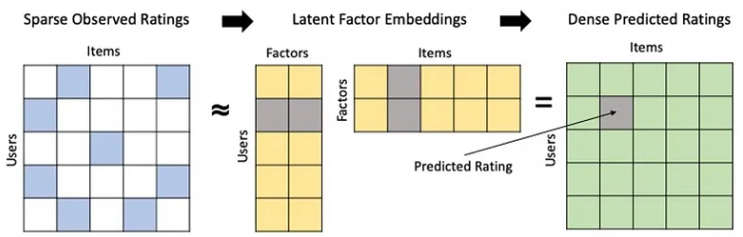

In [40]:
from lightfm import LightFM

# 모델 생성
# warp(Weighted Approximate-Rank Pairwise): 암묵적 피드백에서 자주 쓰임
model = LightFM(loss='warp')

## Training

### 학습 그래프(Precision@K)
- 모델이 제대로 학습되고 있는지 확인할 수 있습니다.

In [41]:
import matplotlib.pyplot as plt
from lightfm.evaluation import precision_at_k

In [42]:
precisions = []

epochs = 30
for epoch in range(epochs):
    model.fit_partial(train, epochs=1, num_threads=2)
    precision = precision_at_k(model, train, k=5).mean()
    precisions.append(precision)
    print(f"Epoch {epoch+1}/{epochs}, Precision@5: {precision:.4f}")

Epoch 1/30, Precision@5: 0.3666
Epoch 2/30, Precision@5: 0.3729
Epoch 3/30, Precision@5: 0.3768
Epoch 4/30, Precision@5: 0.3940
Epoch 5/30, Precision@5: 0.4024
Epoch 6/30, Precision@5: 0.4155
Epoch 7/30, Precision@5: 0.4316
Epoch 8/30, Precision@5: 0.4405
Epoch 9/30, Precision@5: 0.4495
Epoch 10/30, Precision@5: 0.4587
Epoch 11/30, Precision@5: 0.4644
Epoch 12/30, Precision@5: 0.4733
Epoch 13/30, Precision@5: 0.4751
Epoch 14/30, Precision@5: 0.4784
Epoch 15/30, Precision@5: 0.4793
Epoch 16/30, Precision@5: 0.4769
Epoch 17/30, Precision@5: 0.4829
Epoch 18/30, Precision@5: 0.4841
Epoch 19/30, Precision@5: 0.4945
Epoch 20/30, Precision@5: 0.4930
Epoch 21/30, Precision@5: 0.4975
Epoch 22/30, Precision@5: 0.4966
Epoch 23/30, Precision@5: 0.4927
Epoch 24/30, Precision@5: 0.4978
Epoch 25/30, Precision@5: 0.4999
Epoch 26/30, Precision@5: 0.5025
Epoch 27/30, Precision@5: 0.5055
Epoch 28/30, Precision@5: 0.5052
Epoch 29/30, Precision@5: 0.5055
Epoch 30/30, Precision@5: 0.5049


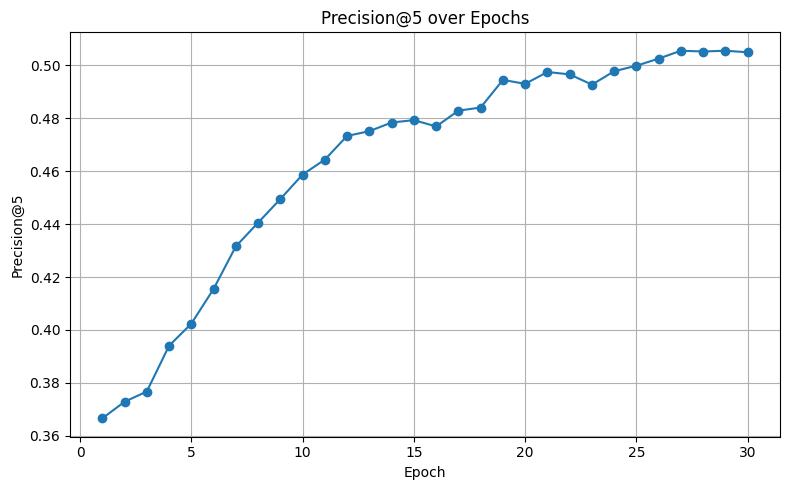

In [43]:
# 그래프 시각화
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), precisions, marker='o')
plt.title('Precision@5 over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Precision@5')
plt.grid(True)
plt.tight_layout()
plt.show()

### 일반적인 모델 학습 코드

In [44]:
# 모델 생성
model = LightFM(loss='warp')

# 모델 학습
model.fit(train, epochs=30, num_threads=2)

## Prediction

In [45]:
# user 0에게 추천할 item 5개
n_users, n_items = interactions.shape
user_id = 0

scores = model.predict(user_id, np.arange(n_items))
top_items = np.argsort(-scores)[:5]

print(f"\nUser {user_id} 추천:")
for item in top_items:
    print(f"  item {item}, 예측 점수: {scores[item]:.2f}")


User 0 추천:
  item 70, 예측 점수: 1.82
  item 92, 예측 점수: 1.65
  item 148, 예측 점수: 1.47
  item 105, 예측 점수: 1.46
  item 151, 예측 점수: 1.41


## Evaluation

### Precision@K
- Precision@K는 추천 시스템에서 자주 사용되는 Top-K 평가 지표 중 하나로, 사용자에게 추천한 K개의 아이템 중 실제로 사용자가 좋아한(또는 상호작용한) 아이템이 몇 개인지를 측정지표이다.
- 높을수록 좋은 성능

In [46]:
from lightfm.evaluation import precision_at_k

precision = precision_at_k(model, test, k=10).mean()
print(f"Precision@10: {precision:.4f}")

Precision@10: 0.0872


### Recall@K
- Recall@K는 추천 시스템에서 사용자가 실제로 좋아하거나 상호작용한 아이템들 중에서, 추천한 K개 중에 몇 개를 맞췄는지를 측정하는 포괄성 평가 지표입니다.
- 값이 클수록 추천이 포괄적으로 잘 됨

In [47]:
from lightfm.evaluation import recall_at_k

recall = recall_at_k(model, test, k=10).mean()
print(f"Recall@10: {recall:.4f}")

Recall@10: 0.1475


## Recommendation

In [48]:
def recommendation_CF(user_id, k=3):
    n_users, n_items = interactions.shape

    # 예측 점수 계산
    scores = model.predict(user_id, np.arange(n_items))

    # 이미 상호작용한 아이템 가져오기
    known_items = interactions.tocsr()[user_id].indices

    # 예측 점수 중 이미 본 아이템은 -inf로 설정하여 제외
    scores[known_items] = -np.inf

    # top-K 추천
    top_items = np.argsort(-scores)

    # 추천 리스트
    rating_prediction ={}
    for item in top_items:
        try:
            unwatched_movie = ratings[ratings['movieId'] == item]['title'].values[0]
            rating_prediction[unwatched_movie] = float(scores[item])
        except:
            pass

    # 가장 높은 예측 평점을 가진 영화들을 추천 결과로 반환
    recommended_movies = pd.DataFrame(rating_prediction.items(), columns=['title', 'predicted_rating'])
    return recommended_movies.sort_values(by=['predicted_rating'], ascending=False)[:k]

In [49]:
recommendation_CF(user_id=0)

,title,predicted_rating
0,Million Dollar Baby,1.823350
1,The Secret Life of Words,1.474587
2,Back to the Future,1.460527


예측 점수가 음수인 경우가 발생할 수 있음   
- 학습 데이터가 부족한 사용자/아이템인 경우(Cold Start) 예측 점수가 작거나 음수일 확률이 높음
- 예측 점수는 양수/음수 모두 가능하며, 값이 중요한 것이 아니라 상대적 우선순위가 중요함

In [50]:
recommendation_CF(user_id=14)

,title,predicted_rating
0,Star Trek: First Contact,-4.725932
1,48 Hrs.,-4.896823
2,Pirates of the Caribbean: Dead Man's Chest,-5.248486
